In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df =pd.read_csv("/Users/joanteng/Downloads/supply_chain_data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location                 10

## **Problem Statement** ##
**Issue 1: Inventory Misalignment**

This section examines whether inventory levels are optimized, including overstocking or stockouts across products.

**Issue 2: Shipping & Logistics Inefficiencies**

This section analyzes inefficiencies related to carrier selection, shipping costs, and delivery times, with the goal of identifying opportunities to optimize logistics performance.

**Issue 3: Supplier Performance Variability**

This section evaluates supplier performance across key dimensions, including manufacturing lead time, cost efficiency, and product quality (defects), to identify inconsistencies and their impact on overall supply chain performance.

## **Data Cleansing**

This section will document all data cleansing and data preparation steps performed during the analysis.

1. check for missing & duplicated values
2. clean up column names & renamed unclear ones
3. check data types, recast columns to numeric, check for NaN
4. added three columns to answer business questions

   inventory_balance = stock_levels - availability
   
   shipping_cost_per_day = shipping_costs / shipping_times
   
   supplier_risk_score = manufacturing_lead_time(30%) + defect_rates(30%) + manufacturing_costs(40%)
   

In [3]:
df.isnull().sum()

Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ','_', regex=False)
    .str.replace('-','_', regex=False)
)

df.rename(columns={
    'lead_times': 'order_lead_time',
    'lead_time': 'supplier_lead_time',
    'costs':'total_supply_chain_costs'
},inplace=True)

In [6]:
df.dtypes

product_type                 object
sku                          object
price                       float64
availability                  int64
number_of_products_sold       int64
revenue_generated           float64
customer_demographics        object
stock_levels                  int64
order_lead_time               int64
order_quantities              int64
shipping_times                int64
shipping_carriers            object
shipping_costs              float64
supplier_name                object
location                     object
supplier_lead_time            int64
production_volumes            int64
manufacturing_lead_time       int64
manufacturing_costs         float64
inspection_results           object
defect_rates                float64
transportation_modes         object
routes                       object
total_supply_chain_costs    float64
dtype: object

In [7]:
numeric_cols = [
    'price', 'availability', 'number_of_products_sold',
    'revenue_generated', 'stock_levels', 'order_lead_time',
    'order_quantities', 'shipping_times', 'shipping_costs',
    'supplier_lead_time', 'production_volumes',
    'manufacturing_lead_time', 'manufacturing_costs',
    'defect_rates', 'total_supply_chain_costs'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.isna().sum()

product_type                0
sku                         0
price                       0
availability                0
number_of_products_sold     0
revenue_generated           0
customer_demographics       0
stock_levels                0
order_lead_time             0
order_quantities            0
shipping_times              0
shipping_carriers           0
shipping_costs              0
supplier_name               0
location                    0
supplier_lead_time          0
production_volumes          0
manufacturing_lead_time     0
manufacturing_costs         0
inspection_results          0
defect_rates                0
transportation_modes        0
routes                      0
total_supply_chain_costs    0
dtype: int64

In [8]:
df['inventory_balance'] = df['stock_levels'] - df['availability']
df['shipping_cost_per_day'] = df['shipping_costs'] / df['shipping_times']
df['supplier_risk_score'] = (
    0.3 * (df['manufacturing_lead_time'] / df['manufacturing_lead_time'].max()) +
    0.3 * (df['defect_rates'] / df['defect_rates'].max()) +
    0.4 * (df['manufacturing_costs'] / df['manufacturing_costs'].max())
)


## **Exploratory Data Analysis** ##

1. Global Data Overview
2. Inventory Misalignment
3. Shipping & Logistics Inefficiencies
4. Supplier Performance

## **1. Global Data Overview** ##

a.Summary statistics

b.Distribution analysis

In [9]:
df.describe()

,price,availability,number_of_products_sold,revenue_generated,stock_levels,order_lead_time,order_quantities,shipping_times,shipping_costs,supplier_lead_time,production_volumes,manufacturing_lead_time,manufacturing_costs,defect_rates,total_supply_chain_costs,inventory_balance,shipping_cost_per_day,supplier_risk_score
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,49.462461,48.400000,460.990000,5776.048187,47.770000,15.960000,49.220000,5.750000,5.548149,17.080000,567.840000,14.77000,47.266693,2.277158,529.245782,-0.630000,1.555703,0.476091
std,31.168193,30.743317,303.780074,2732.841744,31.369372,8.785801,26.784429,2.724283,2.651376,8.846251,263.046861,8.91243,28.982841,1.461366,258.301696,44.487577,1.810919,0.167831
min,1.699976,1.000000,8.000000,1061.618523,0.000000,1.000000,1.000000,1.000000,1.013487,1.000000,104.000000,1.00000,1.085069,0.018608,103.916248,-95.000000,0.145641,0.074805
25%,19.597823,22.750000,184.250000,2812.847151,16.750000,8.000000,26.000000,3.750000,3.540248,10.000000,352.000000,7.00000,22.983299,1.009650,318.778455,-29.500000,0.542878,0.358477
50%,51.239831,43.500000,392.500000,6006.352023,47.500000,17.000000,52.000000,6.000000,5.320534,18.000000,568.500000,14.00000,45.905622,2.141863,520.430444,2.000000,0.941304,0.483916
75%,77.198228,75.000000,704.250000,8253.976921,73.000000,24.000000,71.250000,8.000000,7.601695,25.000000,797.000000,23.00000,68.621026,3.563995,763.078231,33.250000,1.592381,0.596767
max,99.171329,100.000000,996.000000,9866.465458,100.000000,30.000000,96.000000,10.000000,9.929816,30.000000,985.000000,30.00000,99.466109,4.939255,997.413450,92.000000,9.160559,0.775438


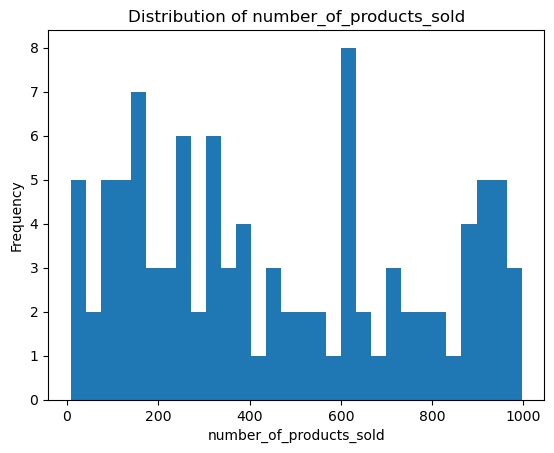

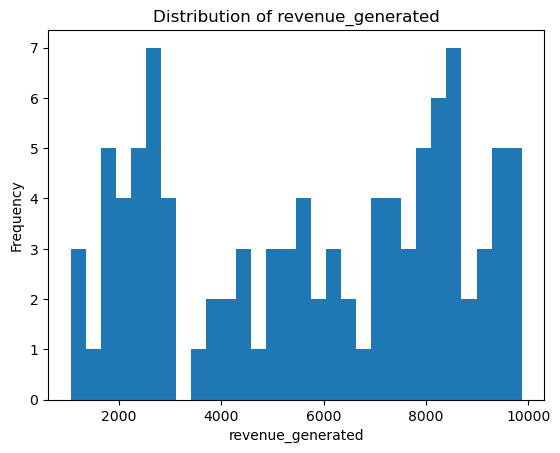

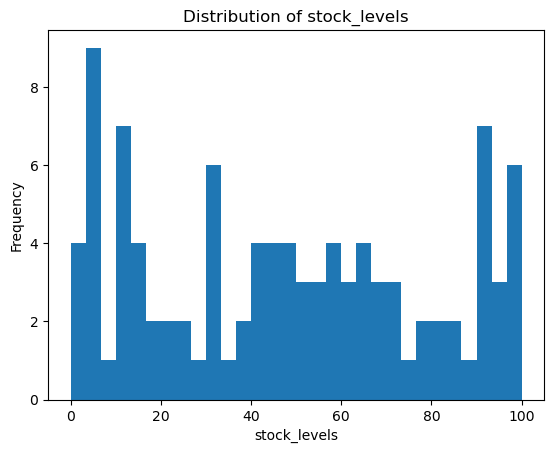

In [10]:
cols = ["number_of_products_sold", "revenue_generated", "stock_levels"]

for col in cols:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

The distributions of key operational variables are relatively uniform across their ranges, indicating that the dataset does not exhibit natural demand clustering. This suggests the data may be simulated or designed to represent a broad range of scenarios rather than real-world skewed demand patterns.

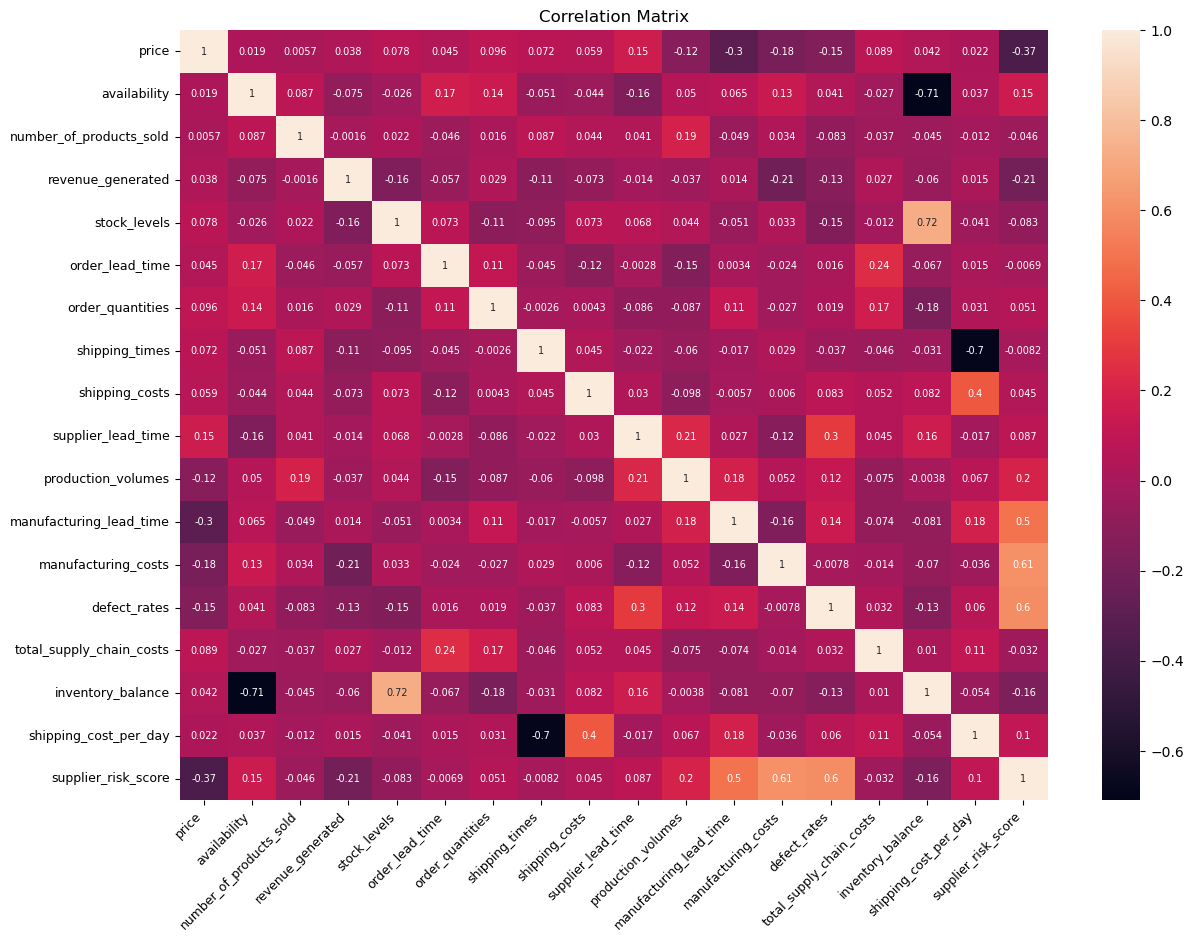

In [11]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True,annot_kws={"size": 7})
plt.title("Correlation Matrix")
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.show()

The correlation analysis reveals that inventory balance is strongly influenced by stock levels and availability, indicating potential instability in inventory management. Shipping cost per day is negatively correlated with shipping time, highlighting a tradeoff between delivery speed and cost efficiency. Additionally, supplier risk score shows strong positive relationships with manufacturing costs, defect rates, and lead times, suggesting that higher-risk suppliers contribute significantly to operational inefficiencies.

## **2. Inventory Misalignment** ##

a. Assessed overall distribution and variability of inventory balance

b. Quantified imbalance rates (overstock vs understock)

c. Segmented analysis by product type to uncover category-level bias

d. Tested potential drivers (cost, lead time) to evaluate root causes

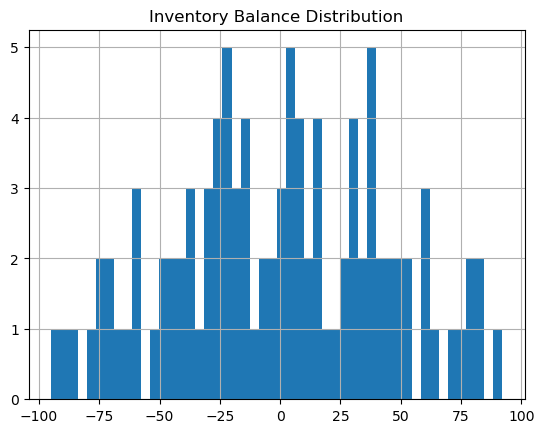

In [12]:
df['inventory_balance'].hist(bins=50)
plt.title("Inventory Balance Distribution")
plt.show()

The distribution is centered around zero but widely spread, indicating both overstock (positive) and understock (negative)across SKUs. This suggests a misalignment problem rather than a systematic bias, with high variability in inventory positioning.

inventory_balance is stock levels minus availability(demand/orders)

In [13]:
print("Mean:", df['inventory_balance'].mean())
print("Std:", df['inventory_balance'].std())

Mean: -0.63
Std: 44.487577428474864


In [14]:
print("Understock mean:",(df['inventory_balance'] < 0).mean())
print("Overstock mean:",(df['inventory_balance'] > 0).mean())

Understock mean: 0.49
Overstock mean: 0.51


The mean inventory balance is near zero, indicating no systemic bias toward overstock or understock. However, the high standard deviation (~44) and nearly equal split between shortages (49%) and excess (51%) indicate significant variability and misallocation at the SKU or location level.

In [15]:
df.groupby('product_type')['inventory_balance'].mean().sort_values()

product_type
skincare    -10.725000
haircare      5.088235
cosmetics     7.423077
Name: inventory_balance, dtype: float64

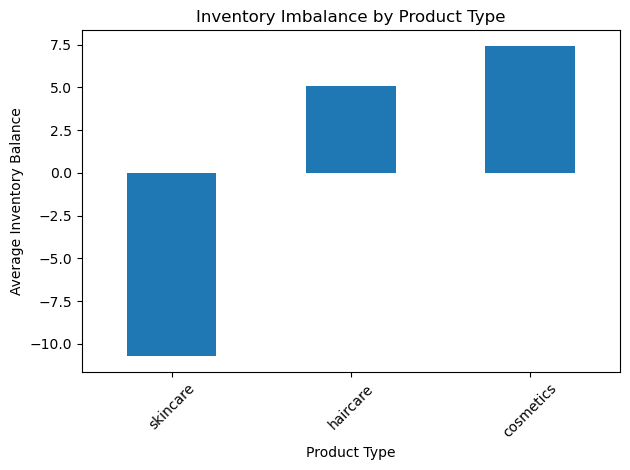

In [16]:
agg = df.groupby('product_type')['inventory_balance'].mean().sort_values()
plt.figure()
agg.plot(kind='bar')
plt.xlabel('Product Type')
plt.ylabel('Average Inventory Balance')
plt.title('Inventory Imbalance by Product Type')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

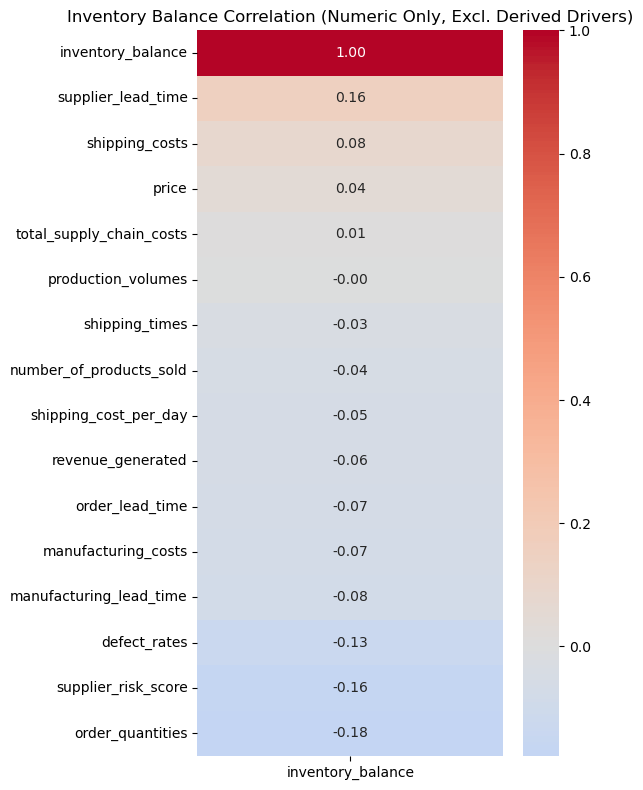

In [17]:
df_numeric = df.select_dtypes(include=['number'])
df_filtered = df_numeric.drop(columns=['stock_levels', 'availability'], errors='ignore')
corr = df_filtered.corr()
target_corr = corr[['inventory_balance']].sort_values(by='inventory_balance', ascending=False)
plt.figure(figsize=(6, 8))
sns.heatmap(
    target_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title('Inventory Balance Correlation (Numeric Only, Excl. Derived Drivers)')
plt.tight_layout()
plt.show()

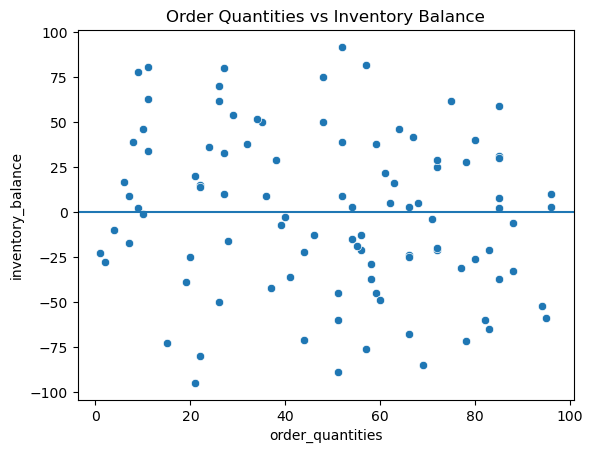

In [18]:
sns.scatterplot(
    data=df,
    x='order_quantities',
    y='inventory_balance'
)

plt.axhline(0)
plt.title('Order Quantities vs Inventory Balance')
plt.show()

In [19]:
df.groupby('product_type')['inventory_balance'].agg(['mean', 'std'])

,mean,std
product_type,,
cosmetics,7.423077,45.803208
haircare,5.088235,41.482649
skincare,-10.725000,45.241793


All product categories exhibit high variability in inventory balance, indicating systemic instability. However, there are clear directional biases: skincare is consistently understocked, while cosmetics and haircare are overstocked. This suggests a combination of global forecasting variability and category-level miscalibration.

The inventory system does not suffer from overall bias but from high variability and misallocation. While supply roughly matches demand in aggregate, there are significant inconsistencies at the category level, with skincare understocked and other categories overstocked. This indicates a combination of forecasting noise and category-level miscalibration.

In [20]:
df[['inventory_balance', 'manufacturing_costs', 'manufacturing_lead_time']].corr()

,inventory_balance,manufacturing_costs,manufacturing_lead_time
inventory_balance,1.000000,-0.069611,-0.080822
manufacturing_costs,-0.069611,1.000000,-0.158098
manufacturing_lead_time,-0.080822,-0.158098,1.000000


Correlation analysis indicates that manufacturing cost and lead time have negligible linear relationships with inventory imbalance, suggesting they are not primary drivers at the aggregate level. The observed imbalance is more likely driven by demand variability or allocation inefficiencies. However, demand forecast data is not available in this dataset, and therefore its impact cannot be assessed within the scope of this analysis.

## **3. Shipping & Logistics Inefficiencies** ##

a.Carrier Performance Comparison

b.Efficiency Analysis

c.Variability / Reliability

d.Link to Inventory


In [21]:
carrier_perf = df.groupby('shipping_carriers')[[
    'shipping_costs',
    'shipping_times',
    'shipping_cost_per_day'
]].agg(['mean', 'std', 'count']).round(2)

carrier_perf

shipping_costs             shipping_times              \
                            mean   std count           mean   std count   
shipping_carriers                                                         
Carrier A                   5.55  2.63    28           6.14  3.17    28   
Carrier B                   5.51  2.86    43           5.30  2.49    43   
Carrier C                   5.60  2.43    29           6.03  2.58    29   

                  shipping_cost_per_day              
                                   mean   std count  
shipping_carriers                                    
Carrier A                          1.60  1.81    28  
Carrier B                          1.66  2.03    43  
Carrier C                          1.36  1.47    29

Carrier C provides the best balance of cost efficiency and reliability, while Carrier B is optimal for speed but introduces higher variability and cost per unit time.

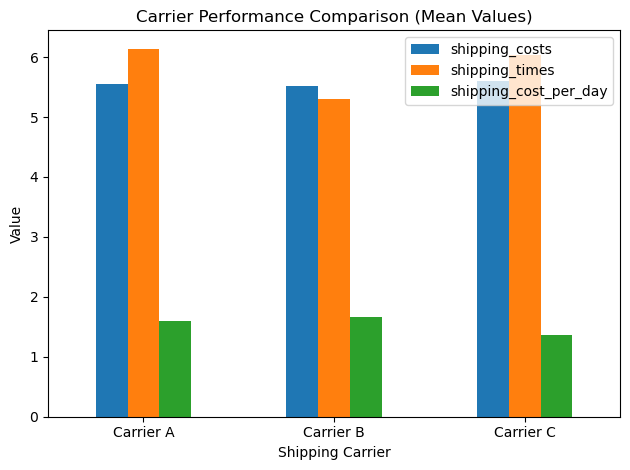

In [22]:
means = carrier_perf.xs('mean', axis=1, level=1)

# Plot
means.plot(kind='bar')

plt.title('Carrier Performance Comparison (Mean Values)')
plt.ylabel('Value')
plt.xlabel('Shipping Carrier')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

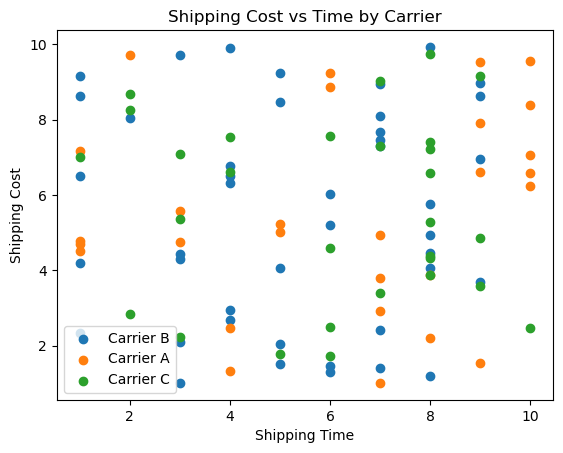

In [23]:
for carrier in df['shipping_carriers'].unique():
    subset = df[df['shipping_carriers'] == carrier]
    plt.scatter(subset['shipping_times'], subset['shipping_costs'], label=carrier)

plt.xlabel('Shipping Time')
plt.ylabel('Shipping Cost')
plt.title('Shipping Cost vs Time by Carrier')
plt.legend()
plt.show()

Carrier C tends to deliver lower cost for similar delivery times, indicating better efficiency
Carrier B shows higher variability, with costs spread widely for similar times
Carrier A is frequently dominated, offering neither speed nor cost advantage

In [24]:
carrier_variability = df.groupby('shipping_carriers')[[
    'shipping_times',
    'shipping_costs'
]].std().rename(columns={
    'shipping_times': 'time_variability',
    'shipping_costs': 'cost_variability'
}).round(2)

carrier_variability

,time_variability,cost_variability
shipping_carriers,,
Carrier A,3.17,2.63
Carrier B,2.49,2.86
Carrier C,2.58,2.43


Carrier C offers the most operational stability with the lowest cost variability and balanced delivery consistency, while Carrier B trades speed for cost volatility and Carrier A shows the highest delivery inconsistency.

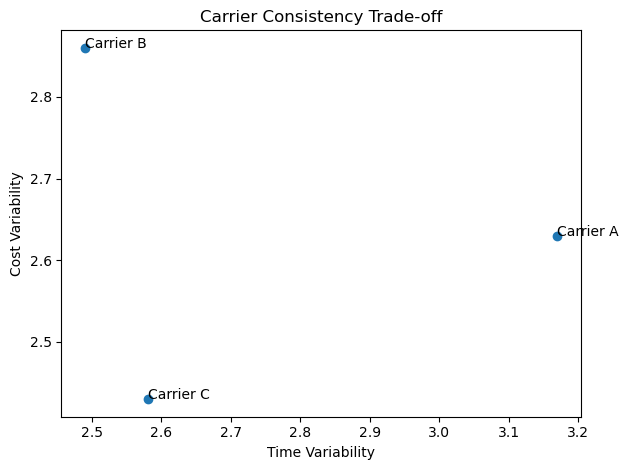

In [25]:
plt.figure()

plt.scatter(
    carrier_variability['time_variability'],
    carrier_variability['cost_variability']
)

# Label points
for carrier in carrier_variability.index:
    plt.text(
        carrier_variability.loc[carrier, 'time_variability'],
        carrier_variability.loc[carrier, 'cost_variability'],
        carrier
    )

plt.xlabel('Time Variability')
plt.ylabel('Cost Variability')
plt.title('Carrier Consistency Trade-off')

plt.tight_layout()
plt.show()

In [26]:
df[['shipping_times', 'inventory_balance']].corr()

,shipping_times,inventory_balance
shipping_times,1.0000,-0.0314
inventory_balance,-0.0314,1.0000


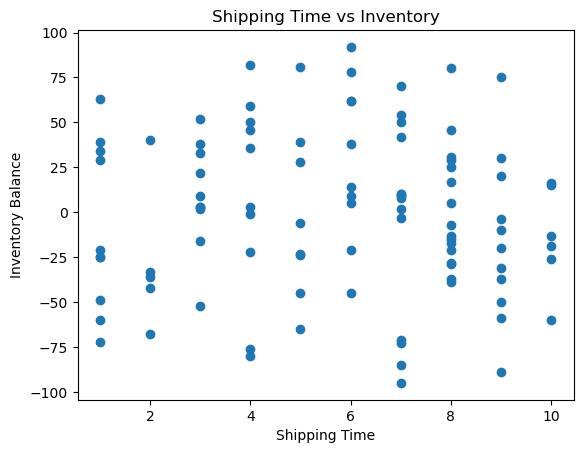

In [27]:
plt.scatter(df['shipping_times'], df['inventory_balance'])
plt.xlabel('Shipping Time')
plt.ylabel('Inventory Balance')
plt.title('Shipping Time vs Inventory')
plt.show()

There is no meaningful relationship between shipping time and inventory balance, as indicated by both near-zero correlation (-0.03) and the absence of any visible pattern in the scatter plot.

**Summary**

Carrier C is the optimal logistics partner, offering the best balance of cost efficiency, reliability, and consistency. Carrier B is suitable for speed-critical scenarios but introduces cost volatility, while Carrier A underperforms across key metrics. Importantly, shipping performance does not significantly impact inventory balance, indicating that inventory issues stem from upstream planning and demand factors rather than carrier selection.

## **3. Supplier Performance** ##

a. Supplier risk score ranking

b. What's driving the risk score? 

c. Manufacturing Lead Time vs Cost 

d. Is Supplier 4 both expensive AND bad quality?

In [28]:
df['supplier_risk_score'] = (
    0.3 * (df['manufacturing_lead_time'] / df['manufacturing_lead_time'].max()) +
    0.3 * (df['defect_rates'] / df['defect_rates'].max()) +
    0.4 * (df['manufacturing_costs'] / df['manufacturing_costs'].max())
)
df['supplier_risk_score'].head(10)


0    0.489865
1    0.730015
2    0.671627
3    0.611565
4    0.591293
5    0.567087
6    0.305157
7    0.434184
8    0.290529
9    0.656374
Name: supplier_risk_score, dtype: float64

In [29]:
supplier_df = df.groupby('supplier_name').agg({
    'manufacturing_lead_time': 'mean',
    'defect_rates': 'mean',
    'manufacturing_costs': 'mean'
}).reset_index()

supplier_df['supplier_risk_score'] = (
    0.3 * (supplier_df['manufacturing_lead_time'] / supplier_df['manufacturing_lead_time'].max()) +
    0.3 * (supplier_df['defect_rates'] / supplier_df['defect_rates'].max()) +
    0.4 * (supplier_df['manufacturing_costs'] / supplier_df['manufacturing_costs'].max())
)


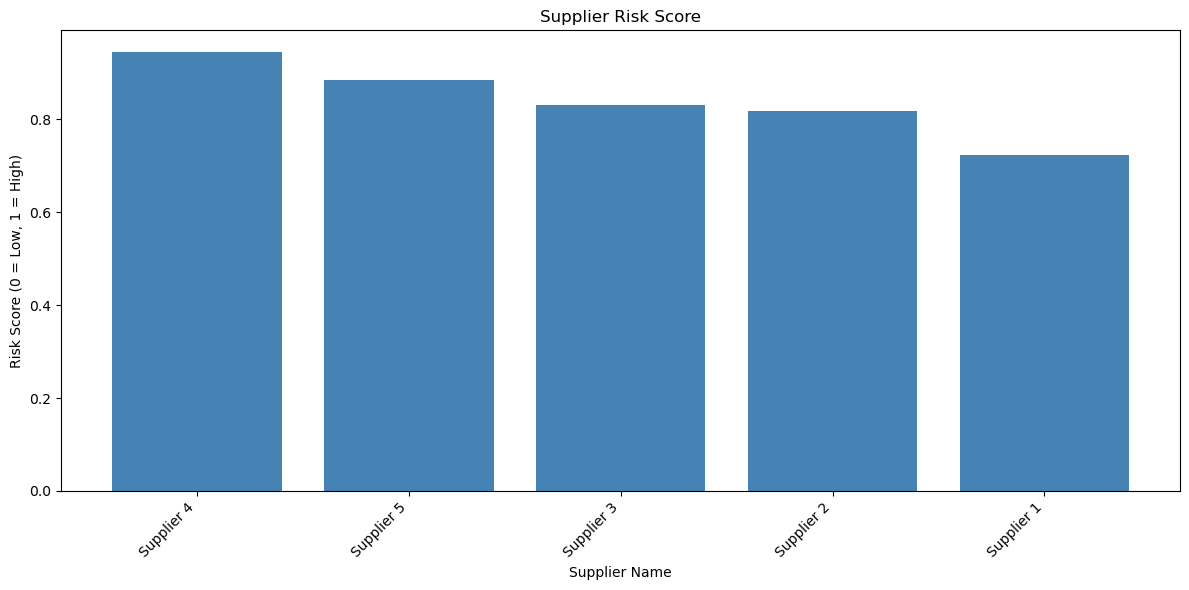

In [30]:
supplier_df_sorted = supplier_df.sort_values('supplier_risk_score', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(supplier_df_sorted['supplier_name'], supplier_df_sorted['supplier_risk_score'], color='steelblue')
plt.title('Supplier Risk Score')
plt.xlabel('Supplier Name')
plt.ylabel('Risk Score (0 = Low, 1 = High)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Supplier 4 is the worst at 0.95, but even Supplier 1 at 0.73 is still in high risk territory. This suggests the issue isn't one bad supplier — it's a systemic problem across the entire supplier base.

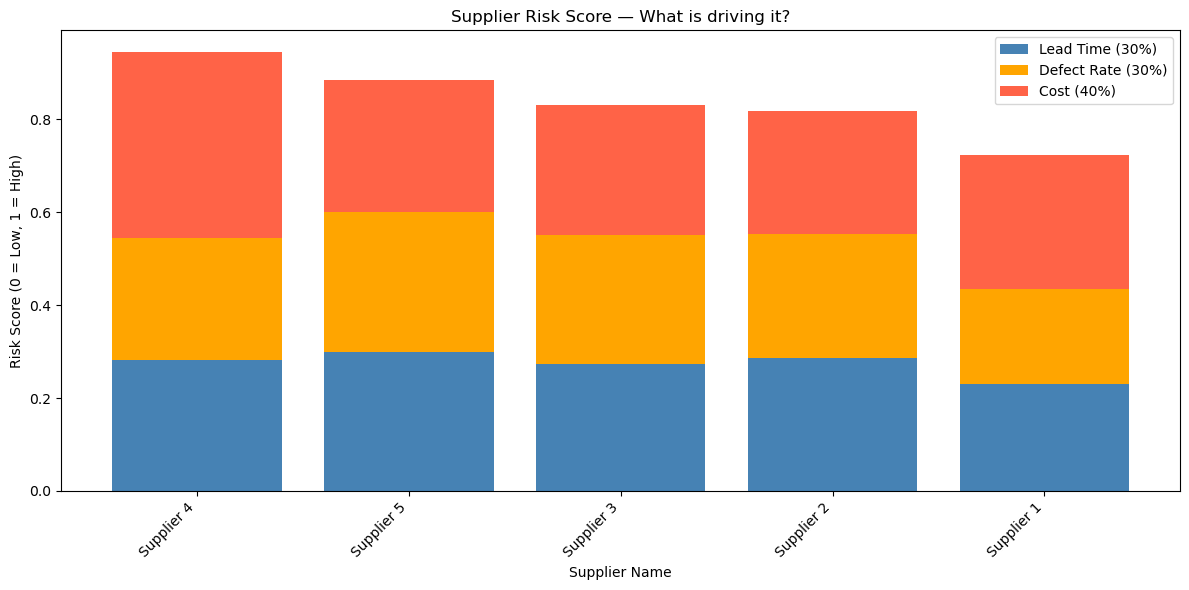

In [31]:
supplier_df['lead_time_component']  = 0.3 * (supplier_df['manufacturing_lead_time'] / supplier_df['manufacturing_lead_time'].max())
supplier_df['defect_component']     = 0.3 * (supplier_df['defect_rates'] / supplier_df['defect_rates'].max())
supplier_df['cost_component']       = 0.4 * (supplier_df['manufacturing_costs'] / supplier_df['manufacturing_costs'].max())

supplier_df_sorted = supplier_df.sort_values('supplier_risk_score', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(supplier_df_sorted['supplier_name'], supplier_df_sorted['lead_time_component'], label='Lead Time (30%)', color='steelblue')
plt.bar(supplier_df_sorted['supplier_name'], supplier_df_sorted['defect_component'],    label='Defect Rate (30%)', color='orange',    bottom=supplier_df_sorted['lead_time_component'])
plt.bar(supplier_df_sorted['supplier_name'], supplier_df_sorted['cost_component'],      label='Cost (40%)',        color='tomato',     bottom=supplier_df_sorted['lead_time_component'] + supplier_df_sorted['defect_component'])

plt.title('Supplier Risk Score — What is driving it?')
plt.xlabel('Supplier Name')
plt.ylabel('Risk Score (0 = Low, 1 = High)')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Cost (red) is the dominant risk driver across almost every supplier. For Supplier 4, Supplier 3, Supplier 2, and Supplier 1, the red segment is the largest — meaning high manufacturing costs are what's pushing their scores up most.
Supplier 5 is a different story. It's the only supplier where defect rate (orange) is the biggest driver, not cost. So while Supplier 4 is the most expensive problem, Supplier 5 has the worst quality problem.
Lead time (blue) is consistently similar across all suppliers — the blue segment is roughly the same height for everyone, meaning no single supplier stands out as unusually slow or fast.

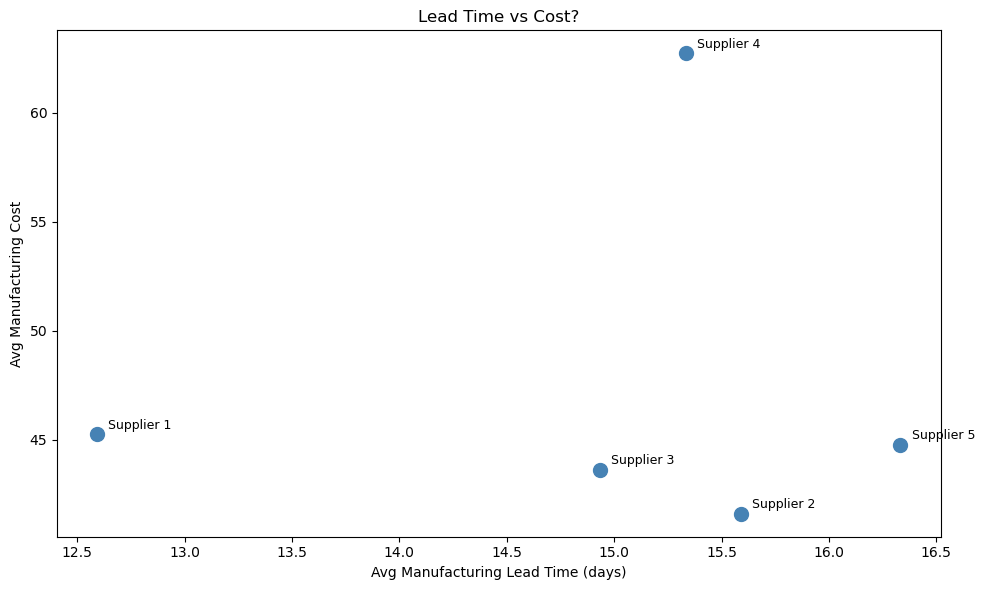

In [32]:
plt.figure(figsize=(10, 6))
plt.scatter(supplier_df['manufacturing_lead_time'], supplier_df['manufacturing_costs'], color='steelblue', s=100)

for i, row in supplier_df.iterrows():
    plt.annotate(row['supplier_name'],
                 (row['manufacturing_lead_time'], row['manufacturing_costs']),
                 textcoords="offset points", xytext=(8, 4), fontsize=9)

plt.title('Lead Time vs Cost?')
plt.xlabel('Avg Manufacturing Lead Time (days)')
plt.ylabel('Avg Manufacturing Cost')
plt.tight_layout()
plt.show()

Supplier 4 is the outlier — similar lead time to Supplier 2 and 5, but costs ~63 vs their ~42-45. You're paying a significant premium for no speed advantage whatsoever
Supplier 1 — fastest delivery at a reasonable cost, worth investing in.

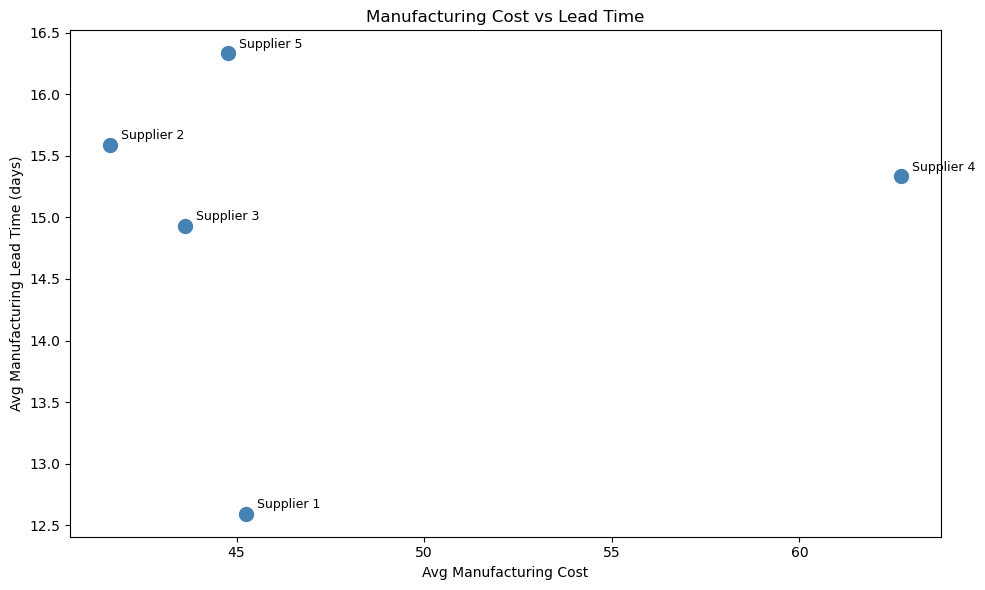

In [35]:
plt.figure(figsize=(10, 6))
plt.scatter(supplier_df['manufacturing_costs'], supplier_df['manufacturing_lead_time'], color='steelblue', s=100)
for i, row in supplier_df.iterrows():
    plt.annotate(row['supplier_name'],
                 (row['manufacturing_costs'], row['manufacturing_lead_time']),
                 textcoords="offset points", xytext=(8, 4), fontsize=9)
plt.title('Manufacturing Cost vs Lead Time')
plt.xlabel('Avg Manufacturing Cost')
plt.ylabel('Avg Manufacturing Lead Time (days)')
plt.tight_layout()
plt.show()

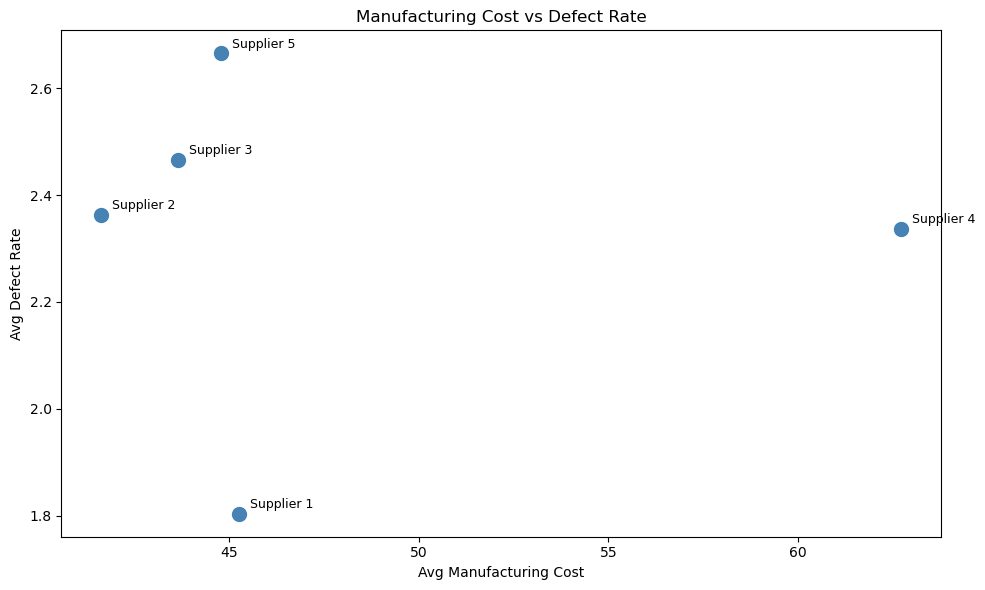

In [33]:
plt.figure(figsize=(10, 6))
plt.scatter(supplier_df['manufacturing_costs'], supplier_df['defect_rates'], color='steelblue', s=100)

for i, row in supplier_df.iterrows():
    plt.annotate(row['supplier_name'],
                 (row['manufacturing_costs'], row['defect_rates']),
                 textcoords="offset points", xytext=(8, 4), fontsize=9)

plt.title('Manufacturing Cost vs Defect Rate')
plt.xlabel('Avg Manufacturing Cost')
plt.ylabel('Avg Defect Rate')
plt.tight_layout()
plt.show()

Supplier 4 is the worst value supplier by far. They're the most expensive at ~63, yet their defect rate (~2.34) is right in the middle of the pack — no better than Supplier 2 who costs less than half as much (~42). 
Supplier 1 is our best value supplier. Similar cost to the cluster (~45) but the lowest defect rate of all five at ~1.80. 
Suppliers 2, 3, and 5 form a cheap cluster — all around cost 42-44, but with higher defect rates. Cheap but unreliable.

**Supplier Performance Analysis — Summary**
Across all four areas explored, Supplier 1 and Supplier 4 sit at opposite ends of the performance spectrum.

Supplier 4 is the highest risk supplier in the portfolio. Cost is the primary driver of that risk score, and the data justifies the concern — they are the most expensive supplier by a significant margin, take no less time to deliver than cheaper alternatives, and still produce average defect rates. There is no dimension on which the premium is earning its value.

Supplier 1 is the strongest performer. They carry the lowest risk score, the fastest lead time, a reasonable cost, and the lowest defect rate of all five suppliers. They represent the benchmark profile the rest of the supplier base should be measured against.

The broader finding is that cost and quality are not correlated in this supplier base — paying more does not buy better quality. This means cost reduction and quality improvement need to be pursued together rather than treated as a tradeoff.
Recommended actions:

Supplier 4 — renegotiate costs or begin evaluating replacements

Supplier 1 — consider increasing order volume as the preferred supplier